# Model training + testing of post-processing methods

In [ ]:
import numpy as np
import pandas as pd

In [36]:
train_subjects = [2, 3, 10, 12, 13, 14, 16, 17, 18, 21]
val_subjects = [1, 5, 6, 7, 11, 15, 20]
test_subjects = [4, 8, 9, 19, 22] 

In [ ]:
def segment_data(df, subjects, w=2, o=0.75, fs=60):
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    
    # Order matters for the Multi-Branch CNN: 8 Ankle channels first, 4 Back channels last
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    X, y = [], []
    
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        data = sub_df[cols].values
        labels = sub_df['fog'].values
        
        for i in range(0, len(data) - win_size, step):
            window = data[i : i + win_size]
            # --- RELATIVE TRANSFORMATION ---
            # Subtract the first sample of the window from the whole window
            window_rel = window - window[0]
            
            X.append(window_rel)
            # Use the mode (most frequent) label for the window
            y.append(pd.Series(labels[i : i + win_size]).mode()[0])
            
    return np.array(X), np.array(y)

# Load your generated quaternions file
df_quat = pd.read_csv('sensor_data_quaternions.csv')

print("Segmenting datasets...")
X_train, y_train = segment_data(df_quat, train_subjects)
X_val, y_val     = segment_data(df_quat, val_subjects)
X_test, y_test   = segment_data(df_quat, test_subjects)

Segmenting datasets...


In [151]:
# Load your generated quaternions file
df_quat = pd.read_csv('sensor_data_complete.csv')

print("Segmenting datasets...")
X_train, y_train, activities_train = segment_data(df_quat, train_subjects)
X_val, y_val, activities_val = segment_data(df_quat, val_subjects)
X_test, y_test, activities_test = segment_data(df_quat, test_subjects)

Segmenting datasets...
Generated 4873 windows for labels and 4873 for activities.
Skipped 363 windows due to NaN values.
Generated 3171 windows for labels and 3171 for activities.
Skipped 126 windows due to NaN values.
Generated 1614 windows for labels and 1614 for activities.
Skipped 743 windows due to NaN values.


In [38]:
import torch
from torch.utils.data import Dataset, DataLoader

class FogDataset(Dataset):
    def __init__(self, X, y):
        # Convert to float32 and move to tensors
        # X shape from segmentation: (Samples, Time, Channels) -> e.g., (N, 120, 12)
        # PyTorch Conv1d expects: (Samples, Channels, Time) -> e.g., (N, 12, 120)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- Usage ---
# Assuming you already have X_train, y_train, etc., from your segmentation script
train_dataset = FogDataset(X_train, y_train)
val_dataset = FogDataset(X_val, y_val)
test_dataset = FogDataset(X_test, y_test)

# DataLoader handles batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiBranchCNN(nn.Module):
    def __init__(self):
        super(MultiBranchCNN, self).__init__()
        
        # Branch 1: Ankles (8 channels: Left q0-q3 + Right q0-q3)
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(8, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Reduces to a single vector
        )
        
        # Branch 2: Back (4 channels: Back q0-q3)
        self.back_branch = nn.Sequential(
            nn.Conv1d(4, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Fusion Layer: Combines 128 (Ankles) + 64 (Back) = 192 features
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.32),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x is assumed to be (Batch, Channels, Time) -> (Batch, 12, 120)
        ankles = x[:, 0:8, :] # First 8 channels
        back = x[:, 8:12, :]  # Last 4 channels
        
        feat_ankles = self.ankle_branch(ankles).view(x.size(0), -1)
        feat_back = self.back_branch(back).view(x.size(0), -1)
        
        # Concatenate branches
        combined = torch.cat((feat_ankles, feat_back), dim=1)
        return self.classifier(combined)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MultiBranchCNN().to(device)
print(f"Model initialized on: {device}")

Model initialized on: mps


In [ ]:
import numpy as np

def train_model(model, train_loader, val_loader, epochs=50, lr=0.008):
    # Setup Optimizer and Loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0036)
    #criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    criterion = nn.BCELoss()
    #criterion = FocalLoss(alpha=0.75, gamma=2.0)

    # Scheduler: Reduces LR if validation loss doesn't improve for 5 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze(-1)
                v_loss = criterion(outputs, labels)
                val_losses.append(v_loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        # Update Scheduler
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_tuned_model_2s.pth')
            print("--> Model Saved!")

# --- START TRAINING ---
train_model(model, train_loader, val_loader)

Epoch 1/50 | Train Loss: 0.3800 | Val Loss: 0.4053 | LR: 0.008000
--> Model Saved!
Epoch 2/50 | Train Loss: 0.3520 | Val Loss: 0.3782 | LR: 0.008000
--> Model Saved!
Epoch 3/50 | Train Loss: 0.3435 | Val Loss: 0.3877 | LR: 0.008000
Epoch 4/50 | Train Loss: 0.3347 | Val Loss: 0.3681 | LR: 0.008000
--> Model Saved!
Epoch 5/50 | Train Loss: 0.3312 | Val Loss: 0.3579 | LR: 0.008000
--> Model Saved!
Epoch 6/50 | Train Loss: 0.3287 | Val Loss: 0.3494 | LR: 0.008000
--> Model Saved!
Epoch 7/50 | Train Loss: 0.3173 | Val Loss: 0.3555 | LR: 0.008000
Epoch 8/50 | Train Loss: 0.3180 | Val Loss: 0.3456 | LR: 0.008000
--> Model Saved!
Epoch 9/50 | Train Loss: 0.3178 | Val Loss: 0.3359 | LR: 0.008000
--> Model Saved!
Epoch 10/50 | Train Loss: 0.3199 | Val Loss: 0.3540 | LR: 0.008000
Epoch 11/50 | Train Loss: 0.3160 | Val Loss: 0.3435 | LR: 0.008000
Epoch 12/50 | Train Loss: 0.3160 | Val Loss: 0.3438 | LR: 0.008000
Epoch 13/50 | Train Loss: 0.3095 | Val Loss: 0.3499 | LR: 0.008000
Epoch 14/50 | Train

In [ ]:
#model.load_state_dict(torch.load('best_tuned_model_1s.pth'))
model.eval()

MultiBranchCNN(
  (ankle_branch): Sequential(
    (0): Conv1d(8, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=False)
    (5): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU()
    (7): AdaptiveAvgPool1d(output_size=1)
  )
  (back_branch): Sequential(
    (0): Conv1d(4, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.5, inplace=False)
    (5): Conv1d(16, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU()
    (7): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_featur

In [47]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, test_loader, device, threshold=0.7):
    """
    Evaluates the model on the test set and returns true labels, predictions, and probabilities.
    This version is corrected to handle single-item batches.
    """
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():  # No gradients needed for evaluation
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            
            # Get model output
            outputs = model(inputs).squeeze()
            
            # --- CORRECTION FOR SINGLE-ITEM BATCH ---
            # If the batch has only one sample, 'outputs' becomes a 0-D tensor (scalar).
            # We need to handle it differently from a 1-D tensor (vector).
            if outputs.dim() == 0:
                # It's a single number, so we append it directly
                all_probs.append(outputs.cpu().item())
                pred = (outputs > threshold).float()
                all_preds.append(pred.cpu().item())
            else:
                # It's a vector for a multi-item batch, so we use extend
                all_probs.extend(outputs.cpu().numpy())
                preds = (outputs > threshold).float()
                all_preds.extend(preds.cpu().numpy())
            
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# --- EXECUTION ---
# Load the best weights saved during training
# Make sure the model is already defined in a previous cell
model.load_state_dict(torch.load('best_tuned_model_1s.pth'))

# Evaluate the model with the corrected function
y_true, y_pred, y_probs = evaluate_model(model, test_loader, device, threshold=0.43)

print("Evaluation completed successfully.")
print(f"y_true length: {len(y_true)}")
print(f"y_pred length: {len(y_pred)}")
print(f"y_probs length: {len(y_probs)}")

Evaluation completed successfully.
y_true length: 4117
y_pred length: 4117
y_probs length: 4117


In [48]:
print("\n" + "="*30)
print("   FINAL TEST RESULTS")
print("="*30)

# 1. Classification Report
print(classification_report(y_true, y_pred, target_names=['Normal', 'FoG']))

# 2. AUC Score (measures how well the model separates the two classes)
auc = roc_auc_score(y_true, y_probs)
print(f"Test AUC-ROC: {auc:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


   FINAL TEST RESULTS
              precision    recall  f1-score   support

      Normal       0.88      0.95      0.92      3311
         FoG       0.71      0.49      0.58       806

    accuracy                           0.86      4117
   macro avg       0.80      0.72      0.75      4117
weighted avg       0.85      0.86      0.85      4117

Test AUC-ROC: 0.8903

Confusion Matrix:
[[3146  165]
 [ 409  397]]


Colonne activité utilisée: activity
Nb fenêtres évaluées: 4117


,activity_id,activity_name,n_windows,fog_prevalence_%,accuracy,precision,recall,f1_score,TP,FP,FN,TN,mean_p_fog
0,0,Activity 0,85,0.000000,0.976471,0.000000,0.000000,0.000000,0,2,0,83,0.054717
1,1,Walking,1717,5.824112,0.938847,0.307692,0.040000,0.070796,4,9,96,1608,0.055053
2,2,Sit,163,0.000000,0.987730,0.000000,0.000000,0.000000,0,2,0,161,0.238256
3,3,Stand,636,0.943396,0.926101,0.063830,0.500000,0.113208,3,44,3,586,0.340545
4,4,Sit-to-Stand,107,0.000000,0.981308,0.000000,0.000000,0.000000,0,2,0,105,0.161592
5,5,Stand-to-Sit,100,0.000000,0.890000,0.000000,0.000000,0.000000,0,11,0,89,0.192952
6,6,Turn Right,518,38.803089,0.739382,0.714286,0.547264,0.619718,110,44,91,273,0.292144
7,7,Turn Left,791,63.084703,0.658660,0.845921,0.561122,0.674699,280,51,219,241,0.370263


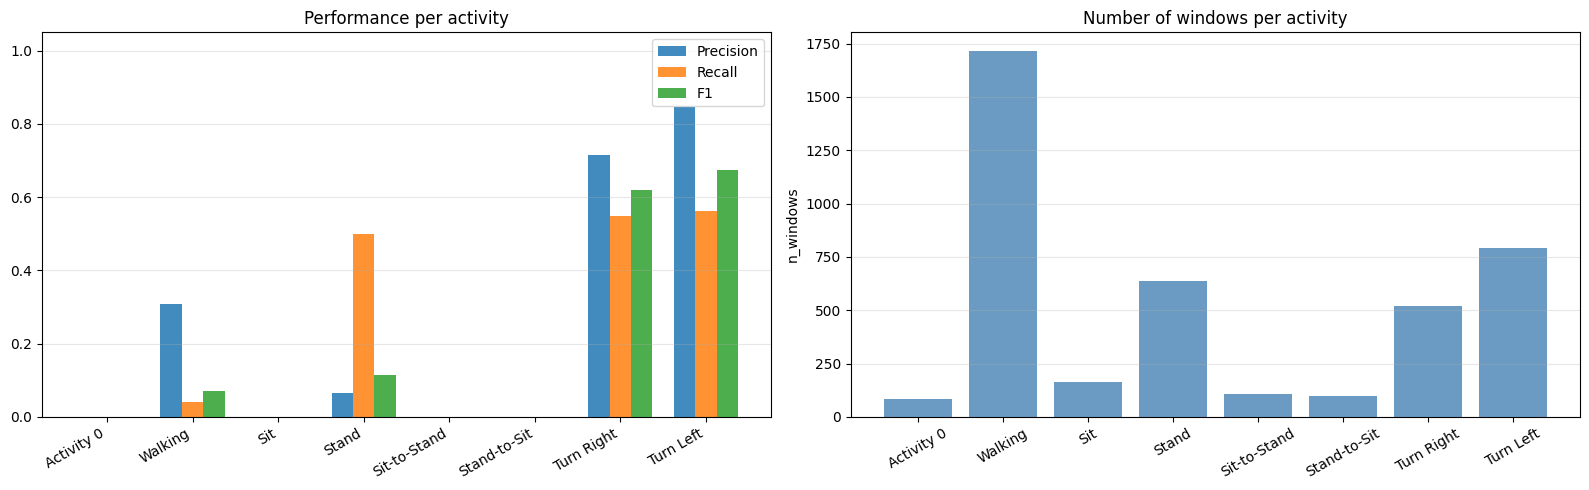


Résumé rapide:
activity_name  n_windows  fog_prevalence_%  precision   recall  f1_score
    Turn Left        791         63.084703   0.845921 0.561122  0.674699
   Turn Right        518         38.803089   0.714286 0.547264  0.619718
        Stand        636          0.943396   0.063830 0.500000  0.113208
      Walking       1717          5.824112   0.307692 0.040000  0.070796
   Activity 0         85          0.000000   0.000000 0.000000  0.000000
          Sit        163          0.000000   0.000000 0.000000  0.000000
 Sit-to-Stand        107          0.000000   0.000000 0.000000  0.000000
 Stand-to-Sit        100          0.000000   0.000000 0.000000  0.000000


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

ACTIVITY_MAP = {
    1: "Walking",
    2: "Sit",
    3: "Stand",
    4: "Sit-to-Stand",
    5: "Stand-to-Sit",
    6: "Turn Right",
    7: "Turn Left"
}

def segment_data_with_activity(df, subjects, w=1, o=0.75, fs=60,
                               label_col="fog", activity_col_candidates=("activity", "activityID", "task", "taskID")):
    """
    Segmente les fenêtres comme segment_data, mais retourne aussi l'activité dominante de chaque fenêtre.
    """
    # Colonnes capteurs (identiques à ton pipeline)
    sensor_cols = [
        "ankleL_q0", "ankleL_q1", "ankleL_q2", "ankleL_q3",
        "ankleR_q0", "ankleR_q1", "ankleR_q2", "ankleR_q3",
        "back_q0", "back_q1", "back_q2", "back_q3"
    ]

    # Détection robuste de la colonne activité
    activity_col = None
    for c in activity_col_candidates:
        if c in df.columns:
            activity_col = c
            break
    if activity_col is None:
        raise ValueError(
            f"Aucune colonne activité trouvée. Colonnes testées: {activity_col_candidates}\n"
            f"Colonnes disponibles: {list(df.columns)}"
        )

    win_size = int(w * fs)
    step = int(win_size * (1 - o))

    X, y, a = [], [], []

    for sub in subjects:
        sub_df = df[df["subjectID"] == sub].reset_index(drop=True)
        if sub_df.empty:
            continue

        data = sub_df[sensor_cols].values
        labels = sub_df[label_col].values
        acts = sub_df[activity_col].values

        for i in range(0, len(data) - win_size, step):
            window = data[i:i + win_size]
            window_rel = window - window[0]  # même preprocessing que ton training

            y_win = pd.Series(labels[i:i + win_size]).mode()[0]
            a_win = pd.Series(acts[i:i + win_size]).mode()[0]

            X.append(window_rel)
            y.append(y_win)
            a.append(a_win)

    return np.array(X), np.array(y), np.array(a), activity_col

subjects_eval = test_subjects
threshold = 0.43

# Segmentation avec activité
X_act, y_act, a_act, activity_col_name = segment_data_with_activity(
    df_quat, subjects_eval, w=1, o=0.75, fs=60
)

print(f"Colonne activité utilisée: {activity_col_name}")
print(f"Nb fenêtres évaluées: {len(X_act)}")

# Dataset / Loader
act_dataset = FogDataset(X_act, y_act)
act_loader = torch.utils.data.DataLoader(act_dataset, batch_size=128, shuffle=False)

# Prédictions modèle
model.eval()
all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    start = 0
    for inputs, labels in act_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze()

        if outputs.dim() == 0:
            outputs = outputs.unsqueeze(0)

        # Robustesse: si le modèle sort des logits, on applique sigmoid
        if (outputs.min() < 0) or (outputs.max() > 1):
            probs = torch.sigmoid(outputs)
        else:
            probs = outputs

        preds = (probs > threshold).int()

        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_true.extend(labels.cpu().numpy().astype(int).tolist())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds, dtype=int)
all_true = np.array(all_true, dtype=int)
all_act = a_act[:len(all_true)]  # alignement sécurité

# =========================
# Métriques par activité
# =========================
rows = []
for act_id in sorted(np.unique(all_act)):
    mask = (all_act == act_id)

    y_t = all_true[mask]
    y_p = all_preds[mask]
    y_pr = all_probs[mask]

    if len(y_t) == 0:
        continue

    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()

    rows.append({
        "activity_id": int(act_id),
        "activity_name": ACTIVITY_MAP.get(int(act_id), f"Activity {int(act_id)}"),
        "n_windows": len(y_t),
        "fog_prevalence_%": 100 * y_t.mean(),
        "accuracy": accuracy_score(y_t, y_p),
        "precision": precision_score(y_t, y_p, zero_division=0),
        "recall": recall_score(y_t, y_p, zero_division=0),
        "f1_score": f1_score(y_t, y_p, zero_division=0),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "mean_p_fog": float(np.mean(y_pr))
    })

perf_by_activity = pd.DataFrame(rows).sort_values("activity_id")
display(perf_by_activity)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Precision / Recall / F1 par activité
x = np.arange(len(perf_by_activity))
w = 0.25
axes[0].bar(x - w, perf_by_activity["precision"], width=w, label="Precision", alpha=0.85)
axes[0].bar(x,     perf_by_activity["recall"],    width=w, label="Recall", alpha=0.85)
axes[0].bar(x + w, perf_by_activity["f1_score"],  width=w, label="F1", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(perf_by_activity["activity_name"], rotation=30, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Performance per activity")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# 2) Volume + prévalence FoG
axes[1].bar(perf_by_activity["activity_name"], perf_by_activity["n_windows"], alpha=0.8, color="steelblue")
axes[1].set_title("Number of windows per activity")
axes[1].set_ylabel("n_windows")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRésumé rapide:")
print(perf_by_activity[["activity_name", "n_windows", "fog_prevalence_%", "precision", "recall", "f1_score"]]
      .sort_values("f1_score", ascending=False)
      .to_string(index=False))

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_prob, thresholds=None):
    """
    Finds the best threshold for classification based on F1-score.

    Args:
        y_true (np.array): True binary labels.
        y_prob (np.array): Predicted probabilities.
        thresholds (list or np.array): List of thresholds to evaluate. Defaults to np.linspace(0.1, 0.9, 33).

    Returns:
        best_threshold (float): The threshold that maximizes the F1-score.
        best_f1 (float): The highest F1-score achieved.
    """
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 33)
    
    best_threshold = 0.0
    best_f1 = -1.0
    
    for thr in thresholds:
        y_pred = (y_prob > thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thr
    
    return best_threshold, best_f1

# Example usage:
best_thr, best_f1 = find_best_threshold(y_val_true, y_val_prob)
print(f"Best Threshold: {best_thr:.2f}, Best F1-Score: {best_f1:.4f}")

Best Threshold: 0.38, Best F1-Score: 0.6267


In [57]:
def get_true_and_probabilities(model, data_loader, device):
    """
    Collects true labels and predicted probabilities from a data loader.

    Args:
        model (torch.nn.Module): The trained model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the dataset (e.g., validation or test).
        device (torch.device): The device to run the model on.

    Returns:
        y_true (np.array): True labels.
        y_prob (np.array): Predicted probabilities.
    """
    model.eval()  # Set model to evaluation mode
    y_true = []
    y_prob = []

    with torch.no_grad():  # No gradients needed for evaluation
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()  # Get model predictions
            
            # Collect true labels and probabilities
            y_true.extend(labels.numpy())
            y_prob.extend(outputs.cpu().numpy())

    return np.array(y_true), np.array(y_prob)

# Example usage:
y_val_true, y_val_prob = get_true_and_probabilities(model, val_loader, device)

In [ ]:
print("\n" + "="*70)
print("ÉVALUATION SUR LE DATASET AVEC THRESHOLDS PAR ACTIVITÉ")
print("="*70)

# 1. Récupérer les prédictions du modèle sur act_loader
print("\n1️ Génération des prédictions sur le dataset...")
model.eval()
all_probs_raw = []
all_preds_raw = []
all_true_raw = []

with torch.no_grad():
    for inputs, labels in act_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze()
        
        # Gestion du cas batch=1
        if outputs.dim() == 0:
            outputs = outputs.unsqueeze(0)
        
        # Appliquer sigmoid si nécessaire
        if (outputs.min() < 0) or (outputs.max() > 1):
            probs = torch.sigmoid(outputs)
        else:
            probs = outputs
        
        all_probs_raw.extend(probs.cpu().numpy().tolist())
        all_true_raw.extend(labels.cpu().numpy().astype(int).tolist())

all_probs_raw = np.array(all_probs_raw)
all_true_raw = np.array(all_true_raw, dtype=int)

print(f"✓ {len(all_probs_raw)} prédictions générées")
print(f"  Plage de probabilités: [{all_probs_raw.min():.4f}, {all_probs_raw.max():.4f}]")

# 2. Appliquer le threshold GLOBAL pour comparaison
print("\n2️⃣ Application du threshold GLOBAL (0.5)...")
global_threshold = 0.43
all_preds_global = (all_probs_raw > global_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

print("\nRésultats avec threshold GLOBAL:")
print(classification_report(all_true_raw, all_preds_global, target_names=['Normal', 'FoG']))
print(f"F1-Score: {f1_score(all_true_raw, all_preds_global):.4f}")

# 3. Appliquer les thresholds PAR ACTIVITÉ
print("\n3️⃣ Application des thresholds PAR ACTIVITÉ...")

# Optionnel: chercher les thresholds optimaux sur le dataset actuel
print("\n  → Trouver les thresholds optimaux par activité...")
optimal_thresholds_local = {}
for act_id in sorted(np.unique(a_act)):
    mask = (a_act == act_id)
    y_t = all_true_raw[mask]
    y_pr = all_probs_raw[mask]
    
    if len(y_t) < 2:
        optimal_thresholds_local[act_id] = 0.5  # défaut
        continue
    
    # Chercher le meilleur threshold basé sur F1
    best_thr = 0.5
    best_f1 = -1
    for thr in np.linspace(0.1, 0.9, 20):
        f1 = f1_score(y_t, (y_pr > thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    
    optimal_thresholds_local[act_id] = best_thr

print("  Thresholds optimaux trouvés:")
for act_id, thr in sorted(optimal_thresholds_local.items()):
    print(f"    Activity {int(act_id)}: {thr:.3f}")

# Appliquer les thresholds optimaux
all_preds_per_activity = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = optimal_thresholds_local.get(act, 0.5)
    all_preds_per_activity[idx] = 1 if all_probs_raw[idx] > thr else 0

print("\nRésultats avec thresholds PAR ACTIVITÉ:")
print(classification_report(all_true_raw, all_preds_per_activity, target_names=['Normal', 'FoG']))
print(f"F1-Score: {f1_score(all_true_raw, all_preds_per_activity):.4f}")

# 4. Détails par activité
print("\n4️⃣ DÉTAILS PAR ACTIVITÉ:")
print("-" * 70)

ACTIVITY_MAP_LOCAL = {
    1: "Walking",
    2: "Sit",
    3: "Stand",
    4: "Sit-to-Stand",
    5: "Stand-to-Sit",
    6: "Turn Right",
    7: "Turn Left"
}

results_per_act = []
for act_id in sorted(np.unique(a_act)):
    mask = (a_act == act_id)
    y_t = all_true_raw[mask]
    y_p = all_preds_per_activity[mask]
    y_pr = all_probs_raw[mask]
    
    if len(y_t) == 0:
        continue
    
    thr = optimal_thresholds_local[act_id]
    
    results_per_act.append({
        'Activity': ACTIVITY_MAP_LOCAL.get(int(act_id), f"Act {int(act_id)}"),
        'N_windows': len(y_t),
        'FoG_%': f"{100*y_t.mean():.1f}",
        'Threshold': f"{thr:.3f}",
        'Accuracy': f"{accuracy_score(y_t, y_p):.3f}",
        'Precision': f"{precision_score(y_t, y_p, zero_division=0):.3f}",
        'Recall': f"{recall_score(y_t, y_p, zero_division=0):.3f}",
        'F1': f"{f1_score(y_t, y_p, zero_division=0):.3f}",
    })

results_df = pd.DataFrame(results_per_act)
print(results_df.to_string(index=False))

# 5. Résumé comparatif
print("\n5️⃣ RÉSUMÉ COMPARATIF:")
print("-" * 70)

comparison = pd.DataFrame({
    'Approche': ['Global (0.5)', 'Per-Activity'],
    'Accuracy': [
        f"{accuracy_score(all_true_raw, all_preds_global):.4f}",
        f"{accuracy_score(all_true_raw, all_preds_per_activity):.4f}"
    ],
    'Precision': [
        f"{precision_score(all_true_raw, all_preds_global, zero_division=0):.4f}",
        f"{precision_score(all_true_raw, all_preds_per_activity, zero_division=0):.4f}"
    ],
    'Recall': [
        f"{recall_score(all_true_raw, all_preds_global, zero_division=0):.4f}",
        f"{recall_score(all_true_raw, all_preds_per_activity, zero_division=0):.4f}"
    ],
    'F1-Score': [
        f"{f1_score(all_true_raw, all_preds_global, zero_division=0):.4f}",
        f"{f1_score(all_true_raw, all_preds_per_activity, zero_division=0):.4f}"
    ]
})

print(comparison.to_string(index=False))

print("\n✓ Évaluation terminée!")


ÉVALUATION SUR LE DATASET AVEC THRESHOLDS PAR ACTIVITÉ

1️⃣ Génération des prédictions sur le dataset...
✓ 4117 prédictions générées
  Plage de probabilités: [0.0000, 0.7427]

2️⃣ Application du threshold GLOBAL (0.5)...

Résultats avec threshold GLOBAL:
              precision    recall  f1-score   support

      Normal       0.88      0.95      0.92      3311
         FoG       0.71      0.49      0.58       806

    accuracy                           0.86      4117
   macro avg       0.80      0.72      0.75      4117
weighted avg       0.85      0.86      0.85      4117

F1-Score: 0.5804

3️⃣ Application des thresholds PAR ACTIVITÉ...

  → Trouver les thresholds optimaux par activité...
  Thresholds optimaux trouvés:
    Activity 0: 0.100
    Activity 1: 0.268
    Activity 2: 0.100
    Activity 3: 0.563
    Activity 4: 0.100
    Activity 5: 0.100
    Activity 6: 0.311
    Activity 7: 0.184

Résultats avec thresholds PAR ACTIVITÉ:
              precision    recall  f1-score   suppo

## Per activity thresholding

In [ ]:

print("="*70)
print("ÉVALUATION AVEC THRESHOLDS PERSONNALISÉS")
print("="*70)

# ÉTAPE 1: Définir vos thresholds personnalisés
print("\n1️ DÉFINIR LES THRESHOLDS POUR CHAQUE ACTIVITÉ")
print("-" * 70)
print("\nModifiez les valeurs ci-dessous selon vos besoins:")
print("(Les thresholds doivent être entre 0 et 1)")
print()

# Dictionnaire des thresholds personnalisés
# À MODIFIER DIRECTEMENT ICI:
custom_thresholds = {
    1: 0.27,  # Walking
    3: 0.56,  # Sit
}

print("Thresholds définis:")
for act_id in sorted(custom_thresholds.keys()):
    act_name = ACTIVITY_MAP_LOCAL.get(int(act_id), f"Activity {int(act_id)}")
    print(f"  Activity {act_id} ({act_name:15s}): {custom_thresholds[act_id]:.3f}")

# ÉTAPE 2: Appliquer les thresholds
print("\n2️ APPLICATION DES THRESHOLDS")
print("-" * 70)

all_preds_custom = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = custom_thresholds.get(act, 0.38)  # Default to 0.5 if activity not defined
    all_preds_custom[idx] = 1 if all_probs_raw[idx] > thr else 0

print(f"✓ {len(all_preds_custom)} prédictions appliquées")

# ÉTAPE 3: Afficher les résultats GLOBAUX
print("\n3️ RÉSULTATS GLOBAUX")
print("-" * 70)

print(classification_report(all_true_raw, all_preds_custom, target_names=['Normal', 'FoG']))

global_metrics = {
    'Accuracy': accuracy_score(all_true_raw, all_preds_custom),
    'Precision': precision_score(all_true_raw, all_preds_custom, zero_division=0),
    'Recall': recall_score(all_true_raw, all_preds_custom, zero_division=0),
    'F1-Score': f1_score(all_true_raw, all_preds_custom, zero_division=0),
    'AUC-ROC': roc_auc_score(all_true_raw, all_probs_raw)
}

for metric_name, metric_value in global_metrics.items():
    print(f"{metric_name:12s}: {metric_value:.4f}")

## Post-processing

In [ ]:
def temporal_smoothing(predictions, window_size=5):
    """
    Applique un lissage temporel avec une moyenne mobile.
    
    Args:
        predictions (np.array): Prédictions binaires (0 ou 1)
        window_size (int): Taille de la fenêtre de lissage
    
    Returns:
        smoothed (np.array): Prédictions lissées
    """
    from scipy.ndimage import uniform_filter1d
    
    # Convertir en float pour appliquer le filtre
    smooth = uniform_filter1d(predictions.astype(float), size=window_size, mode='nearest')
    # Repasser au binaire (seuil 0.5)
    return (smooth > 0.5).astype(int)


def probability_smoothing(probabilities, window_size=5):
    """
    Lisse les probabilités brutes avant application du seuil.
    Utile pour réduire les oscillations.
    
    Args:
        probabilities (np.array): Probabilités brutes [0, 1]
        window_size (int): Taille de la fenêtre de lissage
    
    Returns:
        smoothed_probs (np.array): Probabilités lissées
    """
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(probabilities, size=window_size, mode='nearest')


def hysteresis_threshold(probabilities, low_threshold=0.3, high_threshold=0.7):
    """
    Applique un seuillage par hystérésis (deux seuils).
    Évite les oscillations rapides entre 0 et 1.
    
    Args:
        probabilities (np.array): Probabilités brutes [0, 1]
        low_threshold (float): Seuil bas (passer de 0 à 1)
        high_threshold (float): Seuil haut (passer de 1 à 0)
    
    Returns:
        predictions (np.array): Prédictions [0, 1] avec hystérésis
    """
    predictions = np.zeros_like(probabilities, dtype=int)
    state = 0  # État initial: pas de FoG
    
    for i in range(len(probabilities)):
        prob = probabilities[i]
        
        if state == 0:  # Pas de FoG actuellement
            if prob > high_threshold:
                state = 1  # Transition vers FoG
        else:  # FoG actuellement
            if prob < low_threshold:
                state = 0  # Transition vers pas de FoG
        
        predictions[i] = state
    
    return predictions

def majority_voting(predictions, window_size=5):
    """
    Applique un vote majoritaire sur une fenêtre temporelle.
    
    Args:
        predictions (np.array): Prédictions binaires [0, 1]
        window_size (int): Taille de la fenêtre de vote
    
    Returns:
        voted (np.array): Prédictions après vote majoritaire
    """
    voted = np.zeros_like(predictions)
    half_window = window_size // 2
    
    for i in range(len(predictions)):
        start = max(0, i - half_window)
        end = min(len(predictions), i + half_window + 1)
        window = predictions[start:end]
        # Vote majoritaire: 1 si plus de 50% de 1 dans la fenêtre
        voted[i] = 1 if np.mean(window) > 0.5 else 0
    
    return voted

def remove_small_fragments(predictions, min_duration=3):
    """
    Supprime les fragments isolés trop courts.
    Utile pour éliminer les faux positifs de courte durée.
    
    Args:
        predictions (np.array): Prédictions binaires [0, 1]
        min_duration (int): Durée minimale (en windows) pour conserver une détection
    
    Returns:
        cleaned (np.array): Prédictions nettoyées
    """
    cleaned = predictions.copy()
    
    # Trouver les changements
    changes = np.where(np.diff(np.concatenate([[0], predictions, [0]])) != 0)[0]
    
    # Parcourir les fragments
    for i in range(0, len(changes)-1, 2):
        start, end = changes[i], changes[i+1]
        duration = end - start
        
        # Si le fragment est trop court et c'est un 1 (détection)
        if duration < min_duration and predictions[start] == 1:
            cleaned[start:end] = 0
    
    return cleaned

In [ ]:
print("\n Comparative results:")
print("-" * 70)

# Prédictions de base (sans post-processing)
preds_base = all_preds_custom.copy()

# Appliquer les post-processing
preds_temporal = temporal_smoothing(all_preds_custom, window_size=5)
preds_hysteresis = hysteresis_threshold(all_probs_raw, low_threshold=0.3, high_threshold=0.7)
preds_voting = majority_voting(all_preds_custom, window_size=5)
preds_no_fragments = remove_small_fragments(all_preds_custom, min_duration=3)

# Combinaison: probabilités lissées + custom thresholds + vote
probs_smoothed = probability_smoothing(all_probs_raw, window_size=3)
preds_combined = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = custom_thresholds.get(act, 0.43)
    preds_combined[idx] = 1 if probs_smoothed[idx] > thr else 0
preds_combined = majority_voting(preds_combined, window_size=5)
preds_combined = remove_small_fragments(preds_combined, min_duration=3)

# Comparaison
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

results_pp = pd.DataFrame({
    'Technique': [
        'Base (no PP)',
        'Temporal Smoothing (w=5)',
        'Hysteresis (0.3-0.7)',
        'Majority Voting (w=5)',
        'Remove Fragments (d=3)',
        'Combined (all)',
    ],
    'Accuracy': [
        f"{accuracy_score(all_true_raw, preds_base):.4f}",
        f"{accuracy_score(all_true_raw, preds_temporal):.4f}",
        f"{accuracy_score(all_true_raw, preds_hysteresis):.4f}",
        f"{accuracy_score(all_true_raw, preds_voting):.4f}",
        f"{accuracy_score(all_true_raw, preds_no_fragments):.4f}",
        f"{accuracy_score(all_true_raw, preds_combined):.4f}",
    ],
    'Precision': [
        f"{precision_score(all_true_raw, preds_base, zero_division=0):.4f}",
        f"{precision_score(all_true_raw, preds_temporal, zero_division=0):.4f}",
        f"{precision_score(all_true_raw, preds_hysteresis, zero_division=0):.4f}",
        f"{precision_score(all_true_raw, preds_voting, zero_division=0):.4f}",
        f"{precision_score(all_true_raw, preds_no_fragments, zero_division=0):.4f}",
        f"{precision_score(all_true_raw, preds_combined, zero_division=0):.4f}",
    ],
    'Recall': [
        f"{recall_score(all_true_raw, preds_base, zero_division=0):.4f}",
        f"{recall_score(all_true_raw, preds_temporal, zero_division=0):.4f}",
        f"{recall_score(all_true_raw, preds_hysteresis, zero_division=0):.4f}",
        f"{recall_score(all_true_raw, preds_voting, zero_division=0):.4f}",
        f"{recall_score(all_true_raw, preds_no_fragments, zero_division=0):.4f}",
        f"{recall_score(all_true_raw, preds_combined, zero_division=0):.4f}",
    ],
    'F1-Score': [
        f"{f1_score(all_true_raw, preds_base, zero_division=0):.4f}",
        f"{f1_score(all_true_raw, preds_temporal, zero_division=0):.4f}",
        f"{f1_score(all_true_raw, preds_hysteresis, zero_division=0):.4f}",
        f"{f1_score(all_true_raw, preds_voting, zero_division=0):.4f}",
        f"{f1_score(all_true_raw, preds_no_fragments, zero_division=0):.4f}",
        f"{f1_score(all_true_raw, preds_combined, zero_division=0):.4f}",
    ]
})

print(results_pp.to_string(index=False))

In [ ]:
print("="*70)
print("INTERFACE INTERACTIVE - POST-PROCESSING")
print("="*70)


print("\n⚙️  PARAMÈTRES DE POST-PROCESSING")
print("-" * 70)

# Choisissez la technique à appliquer
technique = "combined"  # Options: "temporal", "probability", "voting", "fragments", "combined"

# Paramètres pour chaque technique
temporal_window = 5           # Temporal Smoothing: taille de fenêtre
prob_window = 3               # Probability Smoothing: taille de fenêtre
voting_window = 5             # Majority Voting: taille de fenêtre
min_duration = 3              # Remove Fragments: durée minimale (en windows)

print(f"Technique sélectionnée: {technique}")
print(f"  - Temporal window: {temporal_window}")
print(f"  - Probability window: {prob_window}")
print(f"  - Voting window: {voting_window}")
print(f"  - Min fragment duration: {min_duration} windows")


print("\n APPLIQUER LA TECHNIQUE")
print("-" * 70)

if technique == "temporal":
    print("Applying Temporal Smoothing...")
    preds_result = temporal_smoothing(all_preds_custom, window_size=temporal_window)
    name = f"Temporal Smoothing (w={temporal_window})"

elif technique == "probability":
    print("Applying Probability Smoothing...")
    probs_smoothed = probability_smoothing(all_probs_raw, window_size=prob_window)
    preds_result = np.zeros_like(all_true_raw)
    for idx in range(len(a_act)):
        act = a_act[idx]
        thr = custom_thresholds.get(act, 0.43)
        preds_result[idx] = 1 if probs_smoothed[idx] > thr else 0
    name = f"Probability Smoothing (w={prob_window})"

elif technique == "voting":
    print("Applying Majority Voting...")
    preds_result = majority_voting(all_preds_custom, window_size=voting_window)
    name = f"Majority Voting (w={voting_window})"

elif technique == "fragments":
    print("Removing Small Fragments...")
    preds_result = remove_small_fragments(all_preds_custom, min_duration=min_duration)
    name = f"Remove Fragments (d={min_duration})"

elif technique == "combined":
    print("Applying Combined Approach (Probability Smoothing + Custom Thresholds + Voting + Remove Fragments)...")
    print("  1. Smoothing probabilities...")
    probs_smoothed = probability_smoothing(all_probs_raw, window_size=prob_window)
    
    print("  2. Applying custom thresholds...")
    preds_temp = np.zeros_like(all_true_raw)
    for idx in range(len(a_act)):
        act = a_act[idx]
        thr = custom_thresholds.get(act, 0.43)
        preds_temp[idx] = 1 if probs_smoothed[idx] > thr else 0
    
    print("  3. Majority voting...")
    preds_temp = majority_voting(preds_temp, window_size=voting_window)
    
    print("  4. Removing short fragments...")
    preds_result = remove_small_fragments(preds_temp, min_duration=min_duration)
    
    name = f"Combined (prob_w={prob_window}, vote_w={voting_window}, min_d={min_duration})"

else:
    print(f" Technique '{technique}' non reconnue!")
    preds_result = all_preds_custom.copy()
    name = "Unknown"

print(f"✓ Technique appliquée: {name}")

print("\n RÉSULTATS DÉTAILLÉS")
print("-" * 70)

# Métriques globales
metrics_result = {
    'Accuracy': accuracy_score(all_true_raw, preds_result),
    'Precision': precision_score(all_true_raw, preds_result, zero_division=0),
    'Recall': recall_score(all_true_raw, preds_result, zero_division=0),
    'F1-Score': f1_score(all_true_raw, preds_result, zero_division=0),
    'AUC-ROC': roc_auc_score(all_true_raw, all_probs_raw)
}

print("\n Métriques Globales:")
for metric_name, metric_value in metrics_result.items():
    print(f"  {metric_name:12s}: {metric_value:.4f}")

# Matrice de confusion
print("\n Matrice de Confusion:")
cm_result = confusion_matrix(all_true_raw, preds_result)
print(f"                Predicted")
print(f"                Normal  FoG")
print(f"Actual Normal   {cm_result[0,0]:5d}  {cm_result[0,1]:5d}")
print(f"       FoG      {cm_result[1,0]:5d}  {cm_result[1,1]:5d}")

# Métriques par activité
print("\n Détails par Activité:")
print("-" * 70)

results_detail = []
for act_id in sorted(np.unique(a_act)):
    mask = (a_act == act_id)
    y_t = all_true_raw[mask]
    y_p = preds_result[mask]
    
    if len(y_t) == 0:
        continue
    
    results_detail.append({
        'Activity': ACTIVITY_MAP_LOCAL.get(int(act_id), f"Act {int(act_id)}"),
        'N_windows': len(y_t),
        'FoG_%': f"{100*y_t.mean():.1f}",
        'Accuracy': f"{accuracy_score(y_t, y_p):.3f}",
        'Precision': f"{precision_score(y_t, y_p, zero_division=0):.3f}",
        'Recall': f"{recall_score(y_t, y_p, zero_division=0):.3f}",
        'F1': f"{f1_score(y_t, y_p, zero_division=0):.3f}",
    })

results_df_detail = pd.DataFrame(results_detail)
print(results_df_detail.to_string(index=False))

print("\n COMPARAISON: Avant vs Après Post-Processing")
print("-" * 70)

comparison_pp = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Sans PP': [
        f"{accuracy_score(all_true_raw, all_preds_custom):.4f}",
        f"{precision_score(all_true_raw, all_preds_custom, zero_division=0):.4f}",
        f"{recall_score(all_true_raw, all_preds_custom, zero_division=0):.4f}",
        f"{f1_score(all_true_raw, all_preds_custom, zero_division=0):.4f}",
    ],
    'Avec PP': [
        f"{metrics_result['Accuracy']:.4f}",
        f"{metrics_result['Precision']:.4f}",
        f"{metrics_result['Recall']:.4f}",
        f"{metrics_result['F1-Score']:.4f}",
    ]
})

print(comparison_pp.to_string(index=False))

# Calcul de l'amélioration
acc_before = accuracy_score(all_true_raw, all_preds_custom)
acc_after = metrics_result['Accuracy']
improvement = ((acc_after - acc_before) / acc_before * 100) if acc_before > 0 else 0

print(f"\n💡 Amélioration d'Accuracy: {improvement:+.2f}%")


print("\n📈 VISUALISATION")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparaison des métriques
ax = axes[0, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_before = [
    accuracy_score(all_true_raw, all_preds_custom),
    precision_score(all_true_raw, all_preds_custom, zero_division=0),
    recall_score(all_true_raw, all_preds_custom, zero_division=0),
    f1_score(all_true_raw, all_preds_custom, zero_division=0),
]
metrics_after = [
    metrics_result['Accuracy'],
    metrics_result['Precision'],
    metrics_result['Recall'],
    metrics_result['F1-Score'],
]

x = np.arange(len(metrics_names))
w = 0.35
ax.bar(x - w/2, metrics_before, w, label='Sans PP', alpha=0.8)
ax.bar(x + w/2, metrics_after, w, label='Avec PP', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=15)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Comparaison des Métriques')
ax.grid(axis='y', alpha=0.3)

# 2. Matrices de confusion (side by side)
ax = axes[0, 1]
cm_before = confusion_matrix(all_true_raw, all_preds_custom)
cm_text = f"Sans PP\nTP:{cm_before[1,1]} FP:{cm_before[0,1]}\nFN:{cm_before[1,0]} TN:{cm_before[0,0]}"
cm_text += f"\n\nAvec PP\nTP:{cm_result[1,1]} FP:{cm_result[0,1]}\nFN:{cm_result[1,0]} TN:{cm_result[0,0]}"
ax.text(0.5, 0.5, cm_text, ha='center', va='center', fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')
ax.set_title('Matrice de Confusion')

# 3. Distribution des prédictions
ax = axes[1, 0]
bins = np.arange(0, len(all_preds_custom) + 100, 100)
ax.hist(np.where(all_preds_custom == 1)[0], bins=bins, alpha=0.6, label='Sans PP', color='orange')
ax.hist(np.where(preds_result == 1)[0], bins=bins, alpha=0.6, label='Avec PP', color='green')
ax.set_xlabel('Index (windows)')
ax.set_ylabel('Nombre de détections FoG')
ax.legend()
ax.set_title('Temporalité des Détections FoG')
ax.grid(axis='y', alpha=0.3)

# 4. Performance par activité
ax = axes[1, 1]
activities = results_df_detail['Activity'].values
f1_scores = [float(x) for x in results_df_detail['F1'].values]
colors = ['green' if f1 > 0.7 else 'orange' if f1 > 0.5 else 'red' for f1 in f1_scores]
ax.barh(activities, f1_scores, color=colors, alpha=0.8)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-Score')
ax.set_title('F1-Score par Activité (Avec PP)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Analyse complète!")
print("\n💡 Conseil: Modifiez les paramètres ci-dessus et réexécutez cette cellule")
print("   pour trouver la meilleure combinaison pour votre cas d'usage.")

In [ ]:
# TEST DE COMBINAISONS: Trouver la meilleure approche

print("="*80)
print("TEST DE COMBINAISONS - POST-PROCESSING")
print("="*80)

# Paramètres de base
prob_window = 5
temporal_window = 5
voting_window = 5
min_duration = 3

print("\n🔬 TESTER DIFFÉRENTES COMBINAISONS")
print("-" * 80)

# Dictionnaire pour stocker les résultats
all_results = []


print("\n[1/8] Baseline (Sans post-processing)...")
preds_1 = all_preds_custom.copy()
name_1 = "Baseline (None)"

results_1 = {
    'name': name_1,
    'accuracy': accuracy_score(all_true_raw, preds_1),
    'precision': precision_score(all_true_raw, preds_1, zero_division=0),
    'recall': recall_score(all_true_raw, preds_1, zero_division=0),
    'f1': f1_score(all_true_raw, preds_1, zero_division=0),
}
all_results.append(results_1)


print("[2/8] Probability Smoothing...")
probs_smoothed = probability_smoothing(all_probs_raw, window_size=prob_window)
preds_2 = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = custom_thresholds.get(act, 0.43)
    preds_2[idx] = 1 if probs_smoothed[idx] > thr else 0

results_2 = {
    'name': f"Probability Smoothing (w={prob_window})",
    'accuracy': accuracy_score(all_true_raw, preds_2),
    'precision': precision_score(all_true_raw, preds_2, zero_division=0),
    'recall': recall_score(all_true_raw, preds_2, zero_division=0),
    'f1': f1_score(all_true_raw, preds_2, zero_division=0),
}
all_results.append(results_2)


print("[3/8] Temporal Smoothing...")
preds_3 = temporal_smoothing(all_preds_custom, window_size=temporal_window)

results_3 = {
    'name': f"Temporal Smoothing (w={temporal_window})",
    'accuracy': accuracy_score(all_true_raw, preds_3),
    'precision': precision_score(all_true_raw, preds_3, zero_division=0),
    'recall': recall_score(all_true_raw, preds_3, zero_division=0),
    'f1': f1_score(all_true_raw, preds_3, zero_division=0),
}
all_results.append(results_3)


print("[4/8] Majority Voting...")
preds_4 = majority_voting(all_preds_custom, window_size=voting_window)

results_4 = {
    'name': f"Majority Voting (w={voting_window})",
    'accuracy': accuracy_score(all_true_raw, preds_4),
    'precision': precision_score(all_true_raw, preds_4, zero_division=0),
    'recall': recall_score(all_true_raw, preds_4, zero_division=0),
    'f1': f1_score(all_true_raw, preds_4, zero_division=0),
}
all_results.append(results_4)

print("[5/8] Probability Smoothing + Voting...")
probs_smoothed = probability_smoothing(all_probs_raw, window_size=prob_window)
preds_temp = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = custom_thresholds.get(act, 0.43)
    preds_temp[idx] = 1 if probs_smoothed[idx] > thr else 0
preds_5 = majority_voting(preds_temp, window_size=voting_window)

results_5 = {
    'name': f"Prob Smoothing + Voting",
    'accuracy': accuracy_score(all_true_raw, preds_5),
    'precision': precision_score(all_true_raw, preds_5, zero_division=0),
    'recall': recall_score(all_true_raw, preds_5, zero_division=0),
    'f1': f1_score(all_true_raw, preds_5, zero_division=0),
}
all_results.append(results_5)


print("[6/8] Probability Smoothing + Remove Fragments...")
probs_smoothed = probability_smoothing(all_probs_raw, window_size=prob_window)
preds_temp = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = custom_thresholds.get(act, 0.43)
    preds_temp[idx] = 1 if probs_smoothed[idx] > thr else 0
preds_6 = remove_small_fragments(preds_temp, min_duration=min_duration)

results_6 = {
    'name': f"Prob Smoothing + Remove Fragments",
    'accuracy': accuracy_score(all_true_raw, preds_6),
    'precision': precision_score(all_true_raw, preds_6, zero_division=0),
    'recall': recall_score(all_true_raw, preds_6, zero_division=0),
    'f1': f1_score(all_true_raw, preds_6, zero_division=0),
}
all_results.append(results_6)


print("[7/8] Voting + Remove Fragments...")
preds_temp = majority_voting(all_preds_custom, window_size=voting_window)
preds_7 = remove_small_fragments(preds_temp, min_duration=min_duration)

results_7 = {
    'name': f"Voting + Remove Fragments",
    'accuracy': accuracy_score(all_true_raw, preds_7),
    'precision': precision_score(all_true_raw, preds_7, zero_division=0),
    'recall': recall_score(all_true_raw, preds_7, zero_division=0),
    'f1': f1_score(all_true_raw, preds_7, zero_division=0),
}
all_results.append(results_7)


print("[8/8] Probability Smoothing + Voting + Remove Fragments...")
probs_smoothed = probability_smoothing(all_probs_raw, window_size=prob_window)
preds_temp = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = custom_thresholds.get(act, 0.43)
    preds_temp[idx] = 1 if probs_smoothed[idx] > thr else 0
preds_temp = majority_voting(preds_temp, window_size=voting_window)
preds_8 = remove_small_fragments(preds_temp, min_duration=min_duration)

results_8 = {
    'name': f"Prob Smoothing + Voting + Remove Fragments",
    'accuracy': accuracy_score(all_true_raw, preds_8),
    'precision': precision_score(all_true_raw, preds_8, zero_division=0),
    'recall': recall_score(all_true_raw, preds_8, zero_division=0),
    'f1': f1_score(all_true_raw, preds_8, zero_division=0),
}
all_results.append(results_8)

print("\n" + "="*80)
print(" RÉSULTATS DE TOUTES LES COMBINAISONS")
print("="*80)

results_df = pd.DataFrame(all_results)
results_df = results_df[['name', 'accuracy', 'precision', 'recall', 'f1']]

# Formater pour l'affichage
display_df = results_df.copy()
display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.4f}")
display_df['precision'] = display_df['precision'].apply(lambda x: f"{x:.4f}")
display_df['recall'] = display_df['recall'].apply(lambda x: f"{x:.4f}")
display_df['f1'] = display_df['f1'].apply(lambda x: f"{x:.4f}")

print("\n")
print(display_df.to_string(index=False))

print("\n" + "="*80)
print(" MEILLEURE COMBINAISON")
print("="*80)

# Par F1-Score
best_idx_f1 = results_df['f1'].idxmax()
best_f1 = results_df.loc[best_idx_f1]
print(f"\n✓ Meilleure F1-Score:")
print(f"  {best_f1['name']}")
print(f"  F1: {best_f1['f1']:.4f} | Acc: {best_f1['accuracy']:.4f} | Prec: {best_f1['precision']:.4f} | Recall: {best_f1['recall']:.4f}")

# Par Accuracy
best_idx_acc = results_df['accuracy'].idxmax()
best_acc = results_df.loc[best_idx_acc]
print(f"\n✓ Meilleure Accuracy:")
print(f"  {best_acc['name']}")
print(f"  Acc: {best_acc['accuracy']:.4f} | F1: {best_acc['f1']:.4f} | Prec: {best_acc['precision']:.4f} | Recall: {best_acc['recall']:.4f}")

# Par Precision
best_idx_prec = results_df['precision'].idxmax()
best_prec = results_df.loc[best_idx_prec]
print(f"\n✓ Meilleure Precision:")
print(f"  {best_prec['name']}")
print(f"  Prec: {best_prec['precision']:.4f} | F1: {best_prec['f1']:.4f} | Acc: {best_prec['accuracy']:.4f} | Recall: {best_prec['recall']:.4f}")

# Par Recall
best_idx_recall = results_df['recall'].idxmax()
best_recall = results_df.loc[best_idx_recall]
print(f"\n✓ Meilleure Recall:")
print(f"  {best_recall['name']}")
print(f"  Recall: {best_recall['recall']:.4f} | F1: {best_recall['f1']:.4f} | Acc: {best_recall['accuracy']:.4f} | Prec: {best_recall['precision']:.4f}")

print("\n" + "="*80)
print(" VISUALISATION COMPARATIVE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Comparaison F1-Score
ax = axes[0, 0]
ax.barh(range(len(results_df)), results_df['f1'], color='steelblue', alpha=0.8)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['name'], fontsize=9)
ax.set_xlabel('F1-Score', fontweight='bold')
ax.set_title('F1-Score par Combinaison', fontweight='bold', fontsize=12)
ax.set_xlim(0, 1)
for i, v in enumerate(results_df['f1']):
    ax.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# 2. Comparaison Accuracy
ax = axes[0, 1]
ax.barh(range(len(results_df)), results_df['accuracy'], color='green', alpha=0.8)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['name'], fontsize=9)
ax.set_xlabel('Accuracy', fontweight='bold')
ax.set_title('Accuracy par Combinaison', fontweight='bold', fontsize=12)
ax.set_xlim(0, 1)
for i, v in enumerate(results_df['accuracy']):
    ax.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# 3. Comparaison Precision vs Recall
ax = axes[1, 0]
x = np.arange(len(results_df))
width = 0.35
ax.barh(x - width/2, results_df['precision'], width, label='Precision', alpha=0.8, color='orange')
ax.barh(x + width/2, results_df['recall'], width, label='Recall', alpha=0.8, color='red')
ax.set_yticks(x)
ax.set_yticklabels(results_df['name'], fontsize=9)
ax.set_xlabel('Score', fontweight='bold')
ax.set_title('Precision vs Recall', fontweight='bold', fontsize=12)
ax.legend()
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# 4. Radar chart (4 métriques)
ax = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

ax = plt.subplot(2, 2, 4, projection='polar')

# Afficher top 3
top_3_indices = results_df.nlargest(3, 'f1').index.tolist()
colors_list = ['gold', 'silver', 'chocolate']

for idx, color in zip(top_3_indices, colors_list):
    values = [
        results_df.loc[idx, 'accuracy'],
        results_df.loc[idx, 'precision'],
        results_df.loc[idx, 'recall'],
        results_df.loc[idx, 'f1']
    ]
    values += values[:1]
    label = results_df.loc[idx, 'name'][:30] + "..." if len(results_df.loc[idx, 'name']) > 30 else results_df.loc[idx, 'name']
    ax.plot(angles, values, 'o-', linewidth=2, label=label, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Top 3 Combinaisons', fontweight='bold', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax.grid(True)

plt.suptitle('Comparaison de toutes les combinaisons', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ Test de combinaisons terminé!")
print("="*80)
print("\n Conseils:")
print("  • Choisissez la combinaison avec la meilleure F1-Score pour l'équilibre")
print("  • Si vous devez minimiser les faux positifs → maximisez Precision")
print("  • Si vous devez minimiser les faux négatifs → maximisez Recall")
print("  • Utilisez la combinaison gagnante dans l'interface interactive!")

In [ ]:

print("\n" + "="*80)
print("OPTIMISATION DES WINDOW SIZES")
print("="*80)

# Définir les plages de window sizes à tester
prob_smooth_sizes = [1, 2, 3, 4, 5]
voting_sizes = [1, 2, 3, 4, 5]


print("\n[PHASE 1] Test de Probability Smoothing seul...")
print("-" * 80)

prob_smooth_results = []

for w in prob_smooth_sizes:
    print(f"  Testing prob_smooth w={w}...", end=" ")
    
    probs_smoothed = probability_smoothing(all_probs_raw, window_size=w)
    preds = np.zeros_like(all_true_raw)
    for idx in range(len(a_act)):
        act = a_act[idx]
        thr = custom_thresholds.get(act, 0.43)
        preds[idx] = 1 if probs_smoothed[idx] > thr else 0
    
    acc = accuracy_score(all_true_raw, preds)
    f1 = f1_score(all_true_raw, preds, zero_division=0)
    prec = precision_score(all_true_raw, preds, zero_division=0)
    rec = recall_score(all_true_raw, preds, zero_division=0)
    
    prob_smooth_results.append({
        'window_size': w,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })
    
    print(f"✓ F1={f1:.4f} | Acc={acc:.4f}")

prob_smooth_df = pd.DataFrame(prob_smooth_results)
print("\n Résultats Probability Smoothing:")
print(prob_smooth_df.to_string(index=False))

print("\n[PHASE 2] Test de Majority Voting seul...")
print("-" * 80)

voting_results = []

for w in voting_sizes:
    print(f"  Testing majority_voting w={w}...", end=" ")
    
    preds = majority_voting(all_preds_custom, window_size=w)
    
    acc = accuracy_score(all_true_raw, preds)
    f1 = f1_score(all_true_raw, preds, zero_division=0)
    prec = precision_score(all_true_raw, preds, zero_division=0)
    rec = recall_score(all_true_raw, preds, zero_division=0)
    
    voting_results.append({
        'window_size': w,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })
    
    print(f"✓ F1={f1:.4f} | Acc={acc:.4f}")

voting_df = pd.DataFrame(voting_results)
print("\n Résultats Majority Voting:")
print(voting_df.to_string(index=False))


print("\n[PHASE 3] Test des combinaisons (Prob Smoothing + Voting)...")
print("-" * 80)

combination_results = []

for prob_w in prob_smooth_sizes:
    for vote_w in voting_sizes:
        print(f"  Testing prob_w={prob_w}, vote_w={vote_w}...", end=" ")
        
        # Probability smoothing
        probs_smoothed = probability_smoothing(all_probs_raw, window_size=prob_w)
        preds_temp = np.zeros_like(all_true_raw)
        for idx in range(len(a_act)):
            act = a_act[idx]
            thr = custom_thresholds.get(act, 0.43)
            preds_temp[idx] = 1 if probs_smoothed[idx] > thr else 0
        
        # Majority voting
        preds = majority_voting(preds_temp, window_size=vote_w)
        
        acc = accuracy_score(all_true_raw, preds)
        f1 = f1_score(all_true_raw, preds, zero_division=0)
        prec = precision_score(all_true_raw, preds, zero_division=0)
        rec = recall_score(all_true_raw, preds, zero_division=0)
        
        combination_results.append({
            'prob_smooth_w': prob_w,
            'voting_w': vote_w,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1
        })
        
        print(f"✓ F1={f1:.4f}")

combination_df = pd.DataFrame(combination_results)


print("\n" + "="*80)
print(" TOP 10 MEILLEURES COMBINAISONS (par F1-Score)")
print("="*80)

top_10 = combination_df.nlargest(10, 'f1')
print("\n")
for idx, row in top_10.iterrows():
    print(f"  {idx+1}. Prob_smooth={int(row['prob_smooth_w']):2d}, Vote={int(row['voting_w']):2d} → "
          f"F1={row['f1']:.4f} | Acc={row['accuracy']:.4f} | "
          f"Prec={row['precision']:.4f} | Rec={row['recall']:.4f}")

print("\n" + "="*80)
print(" VISUALISATION DES RÉSULTATS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap F1-Score des combinaisons
ax = axes[0, 0]
pivot_f1 = combination_df.pivot_table(
    values='f1', 
    index='prob_smooth_w', 
    columns='voting_w', 
    aggfunc='first'
)
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlGn', ax=ax, cbar_kws={'label': 'F1-Score'})
ax.set_title('F1-Score Heatmap (Prob Smoothing vs Voting)', fontweight='bold', fontsize=12)
ax.set_xlabel('Voting Window Size', fontweight='bold')
ax.set_ylabel('Prob Smoothing Window Size', fontweight='bold')

# 2. Heatmap Accuracy
ax = axes[0, 1]
pivot_acc = combination_df.pivot_table(
    values='accuracy', 
    index='prob_smooth_w', 
    columns='voting_w', 
    aggfunc='first'
)
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='Blues', ax=ax, cbar_kws={'label': 'Accuracy'})
ax.set_title('Accuracy Heatmap (Prob Smoothing vs Voting)', fontweight='bold', fontsize=12)
ax.set_xlabel('Voting Window Size', fontweight='bold')
ax.set_ylabel('Prob Smoothing Window Size', fontweight='bold')

# 3. Courbes F1-Score pour chaque technique
ax = axes[1, 0]
ax.plot(prob_smooth_df['window_size'], prob_smooth_df['f1'], 'o-', linewidth=2, 
        markersize=8, label='Prob Smoothing seul', color='steelblue')
ax.plot(voting_df['window_size'], voting_df['f1'], 's-', linewidth=2, 
        markersize=8, label='Majority Voting seul', color='coral')
ax.set_xlabel('Window Size', fontweight='bold')
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_title('F1-Score vs Window Size (Techniques individuelles)', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(prob_smooth_sizes)

# 4. Comparaison Precision vs Recall pour les techniques seules
ax = axes[1, 1]
ax.plot(prob_smooth_df['window_size'], prob_smooth_df['precision'], 'o-', linewidth=2, 
        markersize=8, label='Prob Smoothing - Precision', color='darkblue')
ax.plot(prob_smooth_df['window_size'], prob_smooth_df['recall'], 'o--', linewidth=2, 
        markersize=8, label='Prob Smoothing - Recall', color='lightblue')
ax.plot(voting_df['window_size'], voting_df['precision'], 's-', linewidth=2, 
        markersize=8, label='Voting - Precision', color='darkred')
ax.plot(voting_df['window_size'], voting_df['recall'], 's--', linewidth=2, 
        markersize=8, label='Voting - Recall', color='lightcoral')
ax.set_xlabel('Window Size', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Precision vs Recall (Techniques individuelles)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(prob_smooth_sizes)

plt.suptitle('Analyse des Window Sizes pour Probability Smoothing et Majority Voting', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(" RÉSUMÉ DÉTAILLÉ")
print("="*80)

print("\n Meilleur Probability Smoothing:")
best_prob = prob_smooth_df.loc[prob_smooth_df['f1'].idxmax()]
print(f"   Window Size: {int(best_prob['window_size'])}")
print(f"   F1: {best_prob['f1']:.4f} | Accuracy: {best_prob['accuracy']:.4f}")

print("\n Meilleur Majority Voting:")
best_vote = voting_df.loc[voting_df['f1'].idxmax()]
print(f"   Window Size: {int(best_vote['window_size'])}")
print(f"   F1: {best_vote['f1']:.4f} | Accuracy: {best_vote['accuracy']:.4f}")

print("\n Meilleure Combinaison:")
best_combo = combination_df.loc[combination_df['f1'].idxmax()]
print(f"   Prob Smoothing: {int(best_combo['prob_smooth_w'])}")
print(f"   Majority Voting: {int(best_combo['voting_w'])}")
print(f"   F1: {best_combo['f1']:.4f} | Accuracy: {best_combo['accuracy']:.4f}")
print(f"   Precision: {best_combo['precision']:.4f} | Recall: {best_combo['recall']:.4f}")

print("\n Observations:")
print(f"   • Impact du Prob Smoothing: F1 varie de {prob_smooth_df['f1'].min():.4f} à {prob_smooth_df['f1'].max():.4f}")
print(f"   • Impact du Majority Voting: F1 varie de {voting_df['f1'].min():.4f} à {voting_df['f1'].max():.4f}")
print(f"   • Variance combinée: F1 varie de {combination_df['f1'].min():.4f} à {combination_df['f1'].max():.4f}")

print("\n" + "="*80)

📊 COMPARISON: BASELINE vs PROBABILITY SMOOTHING + VOTING

📈 METRICS:
--------------------------------------------------------------------------------
Metric               Baseline        Prob+Voting     Improvement    
--------------------------------------------------------------------------------
Accuracy             0.8946        0.9239        +0.0293 (+3.3%)
Precision            0.7097        0.8040        +0.0943 (+13.3%)
Recall               0.7739        0.8040        +0.0302 (+3.9%)
F1-Score             0.7404        0.8040        +0.0636 (+8.6%)


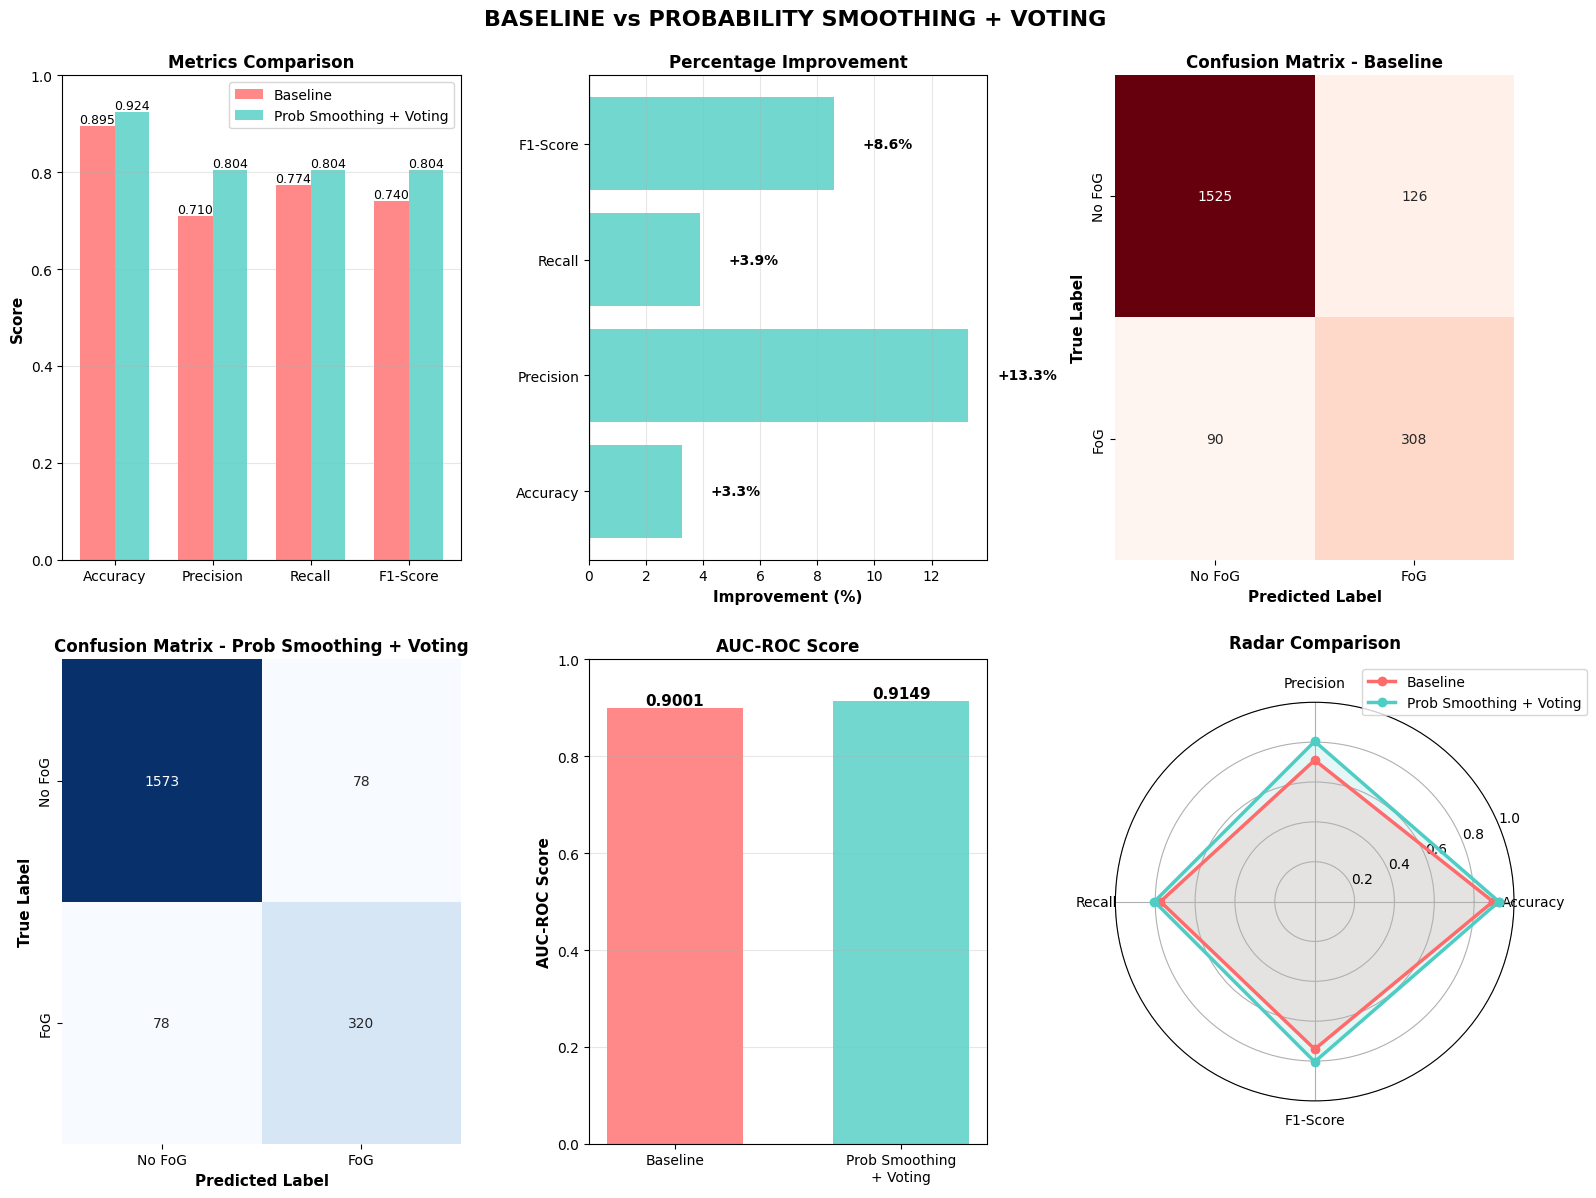


✅ Comparison completed!


In [ ]:
print("="*80)
print(" COMPARISON: BASELINE vs PROBABILITY SMOOTHING + VOTING")
print("="*80)

# Prepare data
baseline_preds = all_preds_custom.copy()
best_preds = results_df.loc[5, 'preds'] if 'preds' in results_df.columns else None

# If preds not stored, recalculate
probs_smoothed = probability_smoothing(all_probs_raw, window_size=3)
best_preds = np.zeros_like(all_true_raw)
for idx in range(len(a_act)):
    act = a_act[idx]
    thr = custom_thresholds.get(act, 0.43)
    best_preds[idx] = 1 if probs_smoothed[idx] > thr else 0
best_preds = majority_voting(best_preds, window_size=5)

# Calculate metrics
baseline_metrics = {
    'Accuracy': accuracy_score(all_true_raw, baseline_preds),
    'Precision': precision_score(all_true_raw, baseline_preds, zero_division=0),
    'Recall': recall_score(all_true_raw, baseline_preds, zero_division=0),
    'F1-Score': f1_score(all_true_raw, baseline_preds, zero_division=0),
}

best_metrics = {
    'Accuracy': accuracy_score(all_true_raw, best_preds),
    'Precision': precision_score(all_true_raw, best_preds, zero_division=0),
    'Recall': recall_score(all_true_raw, best_preds, zero_division=0),
    'F1-Score': f1_score(all_true_raw, best_preds, zero_division=0),
}

# Display metrics
print("\n METRICS:")
print("-" * 80)
print(f"{'Metric':<20} {'Baseline':<15} {'Prob+Voting':<15} {'Improvement':<15}")
print("-" * 80)
for metric in baseline_metrics.keys():
    baseline_val = baseline_metrics[metric]
    best_val = best_metrics[metric]
    improvement = best_val - baseline_val
    improvement_pct = (improvement / baseline_val * 100) if baseline_val > 0 else 0
    
    print(f"{metric:<20} {baseline_val:.4f}        {best_val:.4f}        {improvement:+.4f} ({improvement_pct:+.1f}%)")

fig = plt.figure(figsize=(16, 12))

# 1. Metrics comparison
ax1 = plt.subplot(2, 3, 1)
x_pos = np.arange(len(baseline_metrics))
width = 0.35

baseline_vals = list(baseline_metrics.values())
best_vals = list(best_metrics.values())

bars1 = ax1.bar(x_pos - width/2, baseline_vals, width, label='Baseline', alpha=0.8, color='#FF6B6B')
bars2 = ax1.bar(x_pos + width/2, best_vals, width, label='Prob Smoothing + Voting', alpha=0.8, color='#4ECDC4')

ax1.set_ylabel('Score', fontweight='bold', fontsize=11)
ax1.set_title('Metrics Comparison', fontweight='bold', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(baseline_metrics.keys(), fontsize=10)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Add values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Improvement in %
ax2 = plt.subplot(2, 3, 2)
improvements = []
for metric in baseline_metrics.keys():
    baseline_val = baseline_metrics[metric]
    best_val = best_metrics[metric]
    improvement_pct = (best_val - baseline_val) / baseline_val * 100 if baseline_val > 0 else 0
    improvements.append(improvement_pct)

colors_improvement = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in improvements]
bars = ax2.barh(list(baseline_metrics.keys()), improvements, color=colors_improvement, alpha=0.8)
ax2.set_xlabel('Improvement (%)', fontweight='bold', fontsize=11)
ax2.set_title('Percentage Improvement', fontweight='bold', fontsize=12)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

# Add values
for i, (bar, val) in enumerate(zip(bars, improvements)):
    ax2.text(val + (1 if val > 0 else -1), i, f'{val:+.1f}%', 
            va='center', ha='left' if val > 0 else 'right', fontsize=10, fontweight='bold')

# 3. Confusion Matrix - Baseline
ax3 = plt.subplot(2, 3, 3)
cm_baseline = confusion_matrix(all_true_raw, baseline_preds)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', ax=ax3, cbar=False,
           xticklabels=['No FoG', 'FoG'], yticklabels=['No FoG', 'FoG'])
ax3.set_ylabel('True Label', fontweight='bold', fontsize=11)
ax3.set_xlabel('Predicted Label', fontweight='bold', fontsize=11)
ax3.set_title('Confusion Matrix - Baseline', fontweight='bold', fontsize=12)

# 4. Confusion Matrix - Best
ax4 = plt.subplot(2, 3, 4)
cm_best = confusion_matrix(all_true_raw, best_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
           xticklabels=['No FoG', 'FoG'], yticklabels=['No FoG', 'FoG'])
ax4.set_ylabel('True Label', fontweight='bold', fontsize=11)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=11)
ax4.set_title('Confusion Matrix - Prob Smoothing + Voting', fontweight='bold', fontsize=12)

# 5. ROC-AUC comparison
ax5 = plt.subplot(2, 3, 5)

# Baseline: use raw predictions as "probabilities"
baseline_auc = roc_auc_score(all_true_raw, all_probs_raw)

# Best: use smoothed probabilities
probs_smoothed = probability_smoothing(all_probs_raw, window_size=3)
best_auc = roc_auc_score(all_true_raw, probs_smoothed)

methods = ['Baseline', 'Prob Smoothing\n+ Voting']
auc_scores = [baseline_auc, best_auc]
bars = ax5.bar(methods, auc_scores, color=['#FF6B6B', '#4ECDC4'], alpha=0.8, width=0.6)
ax5.set_ylabel('AUC-ROC Score', fontweight='bold', fontsize=11)
ax5.set_title('AUC-ROC Score', fontweight='bold', fontsize=12)
ax5.set_ylim(0, 1)
ax5.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, auc_scores):
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Radar Chart
ax6 = plt.subplot(2, 3, 6, projection='polar')

categories = list(baseline_metrics.keys())
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

baseline_vals = list(baseline_metrics.values())
baseline_vals += baseline_vals[:1]

best_vals = list(best_metrics.values())
best_vals += best_vals[:1]

ax6.plot(angles, baseline_vals, 'o-', linewidth=2.5, label='Baseline', color='#FF6B6B')
ax6.fill(angles, baseline_vals, alpha=0.15, color='#FF6B6B')

ax6.plot(angles, best_vals, 'o-', linewidth=2.5, label='Prob Smoothing + Voting', color='#4ECDC4')
ax6.fill(angles, best_vals, alpha=0.15, color='#4ECDC4')

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories, fontsize=10)
ax6.set_ylim(0, 1)
ax6.set_title('Radar Comparison', fontweight='bold', fontsize=12, pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=10)
ax6.grid(True)

plt.suptitle('BASELINE vs PROBABILITY SMOOTHING + VOTING', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(" Comparison completed!")
print("="*80)